# **Automated Analysis Pipeline Notebook**
## Diabetes Prediction and Automated Analysis

**Student Name:** `Sarah Christensen`

---

**Dataset:** Pima Indians Diabetes Database (NIH–NIDDK)

**Description:** This dataset contains diagnostic measurements from women aged 21 years or older of Pima Indian heritage. The binary prediction task is to classify whether a patient has diabetes based on the available predictor variables.

**Notebook Purpose:** Demonstrate data exploration, inferential statistics, and automated machine learning workflows, including data ingestion, missing-value handling, preprocessing, model training, and evaluation.

**Note:** This dataset is used for instructional and demonstration purposes only.

### **Assignment Description**

The purpose of the Automated Analysis Pipeline Exploration assignment is to strengthen students' understanding of how structured, reproducible, and adaptive analytical workflows are developed in health data science. Students will execute, examine, and modify a provided automated analysis pipeline to explore how foundational programming concepts, conditional logic, data exploration, and analytical decision-making work together to support automated analyses. This assignment emphasizes analytical reasoning, workflow organization, code readability, reproducibility, and the practical integration of statistical and machine learning methods within a health data science context.

Your task is to implement and execute **at least four additional examples of automated analysis code** in Google Colab beyond those provided. Examine how your workflow responds to dataset characteristics and user-defined goals. Identify the conditional logic used to automate decisions, explain the purpose of each pipeline stage, interpret the outputs (as needed), and modify selected workflow components to demonstrate how those changes affect the analysis. The links below jump to the corresponding code blocks within your copy of the notebook.

**Examples:**
1. **[Automated data ingestion](#scrollTo=OVaf3I1zyE70):** Identifies the file format and uses conditional logic to automatically select the appropriate method for reading and loading the data.

2. **Automated identification and reporting of invalid and missing values:** This process uses two consecutive blocks:
   - **[Identify known impossible values for later imputation](#scrollTo=_1r0rJ1BCX2v):** Uses a predefined list of variables to automatically replace known invalid zeros with missing values. The variable list requires knowledge of the dataset.
   - **[Automatically identify missing values in numeric predictors](#scrollTo=njK9LR0r3c7U):** Automatically identifies numeric predictors and reports their missing-value counts, including missing values created by the preceding block.

   These blocks prepare and inspect the data. Later, the machine learning pipeline fills missing predictors using medians learned from the training set and applies those same medians to the test set.

3. **[Configure and split data for the automated ML pipeline](#scrollTo=0aiR0U5sCiM-):** Uses the specified outcome variable to automatically separate predictors from the outcome, exclude rows with missing outcomes, check for numeric predictors and a binary outcome coded 0/1, and split the data into 70% training and 30% testing while preserving class proportions.

4. **[Automatically preprocess, train, and evaluate ML models](#scrollTo=l7Vt_M-pCpq0):** Automatically fills missing predictors using training-set medians, scales predictors for logistic regression, and trains logistic regression and decision tree models. Evaluates both models on the same test set, displays confusion matrices, and generates a comparison table with accuracy, recall, precision, F1, and ROC AUC scores.

### **My Modifications**

1. **[Adjusted the code for the first joint plot](#scrollTo=id02_MaF9rqT)** to automatically change the title of the plot as the variables are changed in the code. Previously, you had to remember to change both if you changed one.

2. **[Added the fontsize specification](#scrollTo=Rhxnau2BkOlX)** to the axis label code lines for the Logistic Regression ROC-AUC plot, so that the axis labels would end up in the final plot, in order to provide more information for interpretation.

3. **[Remade the first confusion matrices](#scrollTo=ikvepq6y53g2)** for both the logistic regression and decision tree models, but with the function that was created earlier in the notebook, make_confusion_matrix() which had all the details defined and specific labels, instead of the one that was imported with the sklearn.metrics library, ConfusionMatrixDisplay.from_predictions(). This was able to make the confusion matrices more automatic.

4. **[Combined the two code chunks](#scrollTo=6maD2uCTDO9q)** after the optimal cutoff was calculated with the cross validation method. The confusion matrix was remade according to the cutoff and then the F1 calculation after cutoff, of both the test and training set, were then compared. This removed the repeated code for calculating the test set after the cuffoff more than once, and also provided a little more context to the change.

In [1]:
# @title **Upload your dataset**

from google.colab import files
import pandas as pd
import io
from pathlib import Path

uploaded = files.upload()

if len(uploaded) != 1:
    raise ValueError("Please upload exactly one data file.")

filename = next(iter(uploaded))
extension = Path(filename).suffix.lower()
file_data = io.BytesIO(uploaded[filename])

if extension in [".csv", ".tsv", ".txt"]:
    # Automatically detect the delimiter.
    df = pd.read_csv(file_data, sep=None, engine="python")

elif extension in [".xlsx", ".xls"]:
    # Load the first worksheet.
    df = pd.read_excel(file_data)

elif extension == ".json":
    df = pd.read_json(file_data)

elif extension == ".parquet":
    df = pd.read_parquet(file_data)

else:
    raise ValueError(
        f"'{extension}' files require a different reader. "
        "Supported formats: CSV, TSV, TXT, XLSX, XLS, JSON, and Parquet."
    )

print(f"Successfully loaded: {filename}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

display(df.head())

Saving Example Dataset_Diabetes.csv to Example Dataset_Diabetes (2).csv
Successfully loaded: Example Dataset_Diabetes (2).csv
Rows: 768 | Columns: 9


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


 The above chunk of code sets up the environment and you to upload the file for analysis. It uses conditional statements to be able to read in multiple types of date files, but then also will print an informative error message if a file type would not work.

In [2]:
# @title **View first 10 rows of data**

df.head(20) # CHANGE NUMBER TO INCREASE OR DECREASE THE NUMBER OF ROWS

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
# @title **View a list of all variables**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
attribute_list = list(df.columns)
print("Variables in the dataset:")
print("")
print(attribute_list)

Variables in the dataset:

['Pregnancies', 'Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']


In [4]:
# @title **View the number of rows and columns in the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
print("Number of rows and columns:")
print("")
df.shape   # (rows, columns)

Number of rows and columns:



(768, 9)

In [5]:
# @title **View general information about the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pregnancies     768 non-null    int64  
 1   Glucose         768 non-null    int64  
 2   D_BP            768 non-null    int64  
 3   Skin_Thickness  768 non-null    int64  
 4   Insulin         768 non-null    int64  
 5   BMI             768 non-null    float64
 6   Pedigree        768 non-null    float64
 7   Age             768 non-null    int64  
 8   Outcome         768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# @title **Describe the data (and data type) for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Describe all columns
summary = df.describe(include='all').T

# Replace NaN values with 'NA'
summary = summary.fillna('NA')

# Insert formatted variable name + data type
summary.insert(
    0,
    'Variable',
    [f"<b>{col}</b><br><span style='font-weight:normal; font-size:smaller;'>[{df[col].dtype}]</span>" for col in summary.index]
)

# Reset index to clean up formatting
summary.reset_index(drop=True, inplace=True)

# Format numeric columns to 3 decimal places only
styled_summary = (
    summary.style
    .format(precision=3, na_rep="NA")  # Format numbers to 3 decimals
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .hide(axis='index')  # Remove default row index
)

styled_summary

Variable,count,mean,std,min,25%,50%,75%,max
Pregnancies[int64],768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose[int64],768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
D_BP[int64],768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
Skin_Thickness[int64],768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin[int64],768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI[float64],768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
Pedigree[float64],768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age[int64],768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome[int64],768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [7]:
# @title **Identify known impossible values for later imputation**

import numpy as np

variables_to_replace_zeros = [
    'Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI'
]

for variable in variables_to_replace_zeros:
    if variable in df.columns:
        df[variable] = df[variable].replace(0, np.nan)

print("Impossible zeros replaced with missing values.")
print("The ML pipeline will impute missing predictors using training data.")

Impossible zeros replaced with missing values.
The ML pipeline will impute missing predictors using training data.


The above chunk of code uses conditional statements for replacing only specific zeros with nan.

In [8]:
# @title **Automatically identify other missing values in numeric predictors**

target_variable = "Outcome"

# Automatically identify numeric predictors.
numeric_predictors = df.select_dtypes(include="number").columns
numeric_predictors = numeric_predictors.drop(
    target_variable, errors="ignore"
)

# Count missing values.
missing_counts = df[numeric_predictors].isna().sum()
predictors_with_missing = missing_counts[missing_counts > 0]

if predictors_with_missing.empty:
    print("No missing values detected in numeric predictors.")
else:
    print("Predictors requiring imputation:")
    display(predictors_with_missing.rename("Missing values").to_frame())
    print("Block #4 will automatically fill these using training-set medians.")

Predictors requiring imputation:


,Missing values
Glucose,5
D_BP,35
Skin_Thickness,227
Insulin,374
BMI,11


Block #4 will automatically fill these using training-set medians.


The above chunk of code sums up the number of missing values in each of the numeric columns, after identifying which columns were numeric. Then uses conditional logic to provide informational output.

In [9]:
# @title **Description of just one variable**

# Define the variable name (this can be dynamic)
variable = 'Insulin'  # CHANGE VARIABLE HERE


#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Print the title dynamically
print(f"Quantitative Description of {variable}:")
print("")

# Get the description and round it to 3 decimal places
description = df[variable].describe().round(3)

# Print the rounded description
print(description)

Quantitative Description of Insulin:

count    394.000
mean     155.548
std      118.776
min       14.000
25%       76.250
50%      125.000
75%      190.000
max      846.000
Name: Insulin, dtype: float64


The code above allows one to easily look at different variables by only having to change one word of code.

In [10]:
# @title **Number of responses and missing values for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Count non-null and missing responses
response_counts = df.count()
missing_counts = df.isnull().sum()

# Combine into one DataFrame
df_count = pd.DataFrame({
    'Variable': response_counts.index,
    '# of Responses': response_counts.values,
    '# Missing': missing_counts.values
})

# Display as styled table: bold headers and center-aligned values
df_count.style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Variable,# of Responses,# Missing
0,Pregnancies,768,0
1,Glucose,763,5
2,D_BP,733,35
3,Skin_Thickness,541,227
4,Insulin,394,374
5,BMI,757,11
6,Pedigree,768,0
7,Age,768,0
8,Outcome,768,0


In [11]:
# @title **View 15 random rows of data**
np.random.seed()
df.sample(n=20) # CHANGE NUMBER HERE TO INCREASE OR DECREASE NUMBER OF RANDOM ROWS

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
145,0,102.0,75.0,23.0,NaN,NaN,0.572,21,0
202,0,108.0,68.0,20.0,NaN,27.3,0.787,32,0
136,0,100.0,70.0,26.0,50.0,30.8,0.597,21,0
676,9,156.0,86.0,NaN,NaN,24.8,0.230,53,1
234,3,74.0,68.0,28.0,45.0,29.7,0.293,23,0
215,12,151.0,70.0,40.0,271.0,41.8,0.742,38,1
677,0,93.0,60.0,NaN,NaN,35.3,0.263,25,0
233,4,122.0,68.0,NaN,NaN,35.0,0.394,29,0
91,4,123.0,80.0,15.0,176.0,32.0,0.443,34,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1


In [12]:
# @title **Change a variable's data type (e.g., from integer to category)**

# Choose variable to change
variable_to_change = 'Pregnancies' # CHANGE THIS VARIABLE
new_data_type = 'int64' # CHANGE THIS TO THE NEW DATA TYPE (options include category, int64, float)

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
# Capture original data type
original_dtype = df[variable_to_change].dtype

# Change data type (options include category, float, int64)
df[variable_to_change] = df[variable_to_change].astype(new_data_type)

# Capture new data type
new_dtype = df[variable_to_change].dtype

# Print result dynamically
print(f"'{variable_to_change}' variable changed from {original_dtype} to {new_dtype}")
print("")
print("Note: You can revise the code to change the data type for a different variable.")

'Pregnancies' variable changed from int64 to int64

Note: You can revise the code to change the data type for a different variable.


The above chunk of code allows one to easily change the data type of one of the variables, while also providing documentation of the change.

## **Exploratory Data Analysis**

In [13]:
# @title **Pearson's correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
D_BP,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
Skin_Thickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
Pedigree,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


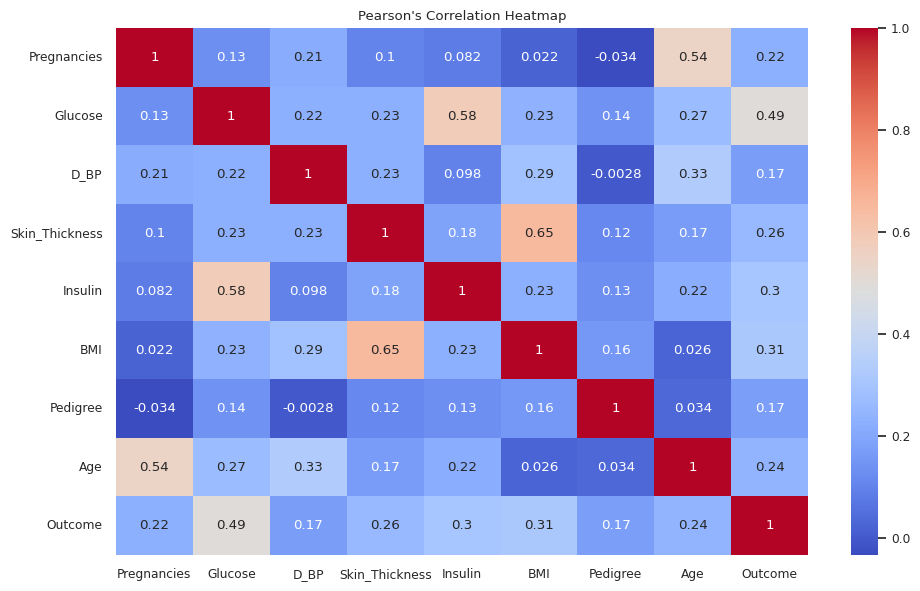

In [14]:
# @title **Pearson's correlation heatmap**

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson's Correlation Heatmap")
plt.tight_layout()
plt.show()

The above chunk of code took the Pearson's correlation table and turned it into a heatmap, visualizing the difference in the relationship of the variables. There seems to be the highest correlation between BMI and Skin Thickness with a correlation coefficient of 0.65, with Insulin and Glucose and then Age and Pregnancies to have the next highest coefficients.

In [15]:
# @title **Spearman's Rank correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr(method='spearman')

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.000000,0.129547,0.194103,0.086734,0.127859,0.000279,-0.043242,0.607216,0.198689
Glucose,0.129547,1.000000,0.249415,0.229815,0.658813,0.227761,0.090596,0.283315,0.483364
D_BP,0.194103,0.249415,1.000000,0.248017,0.130463,0.299176,0.008511,0.370609,0.177227
Skin_Thickness,0.086734,0.229815,0.248017,1.000000,0.245188,0.685380,0.074979,0.231132,0.265397
Insulin,0.127859,0.658813,0.130463,0.245188,1.000000,0.303515,0.130262,0.267437,0.377300
BMI,0.000279,0.227761,0.299176,0.685380,0.303515,1.000000,0.136138,0.121119,0.309324
Pedigree,-0.043242,0.090596,0.008511,0.074979,0.130262,0.136138,1.000000,0.042909,0.175353
Age,0.607216,0.283315,0.370609,0.231132,0.267437,0.121119,0.042909,1.000000,0.309040
Outcome,0.198689,0.483364,0.177227,0.265397,0.377300,0.309324,0.175353,0.309040,1.000000


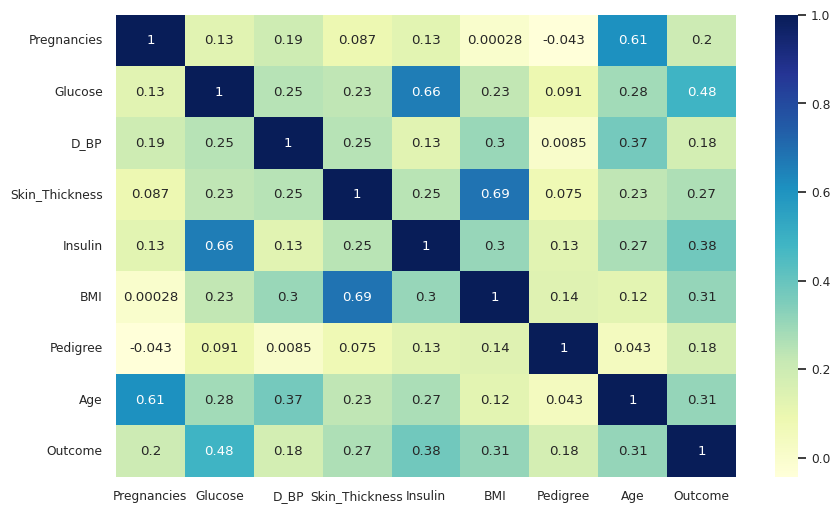

In [16]:
# @title **Spearman's Rank correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(method='spearman'), annot=True, cmap="YlGnBu");

The above chunk of code plots the Spearman's Rank Correlation Table as a heatmap. Even though the values of the coefficients are slightly different, it shows a similar pattern for the variables that are most correlated, like BMI and Skin Thickness. This correlation heatmap also includes the Outcome variable.

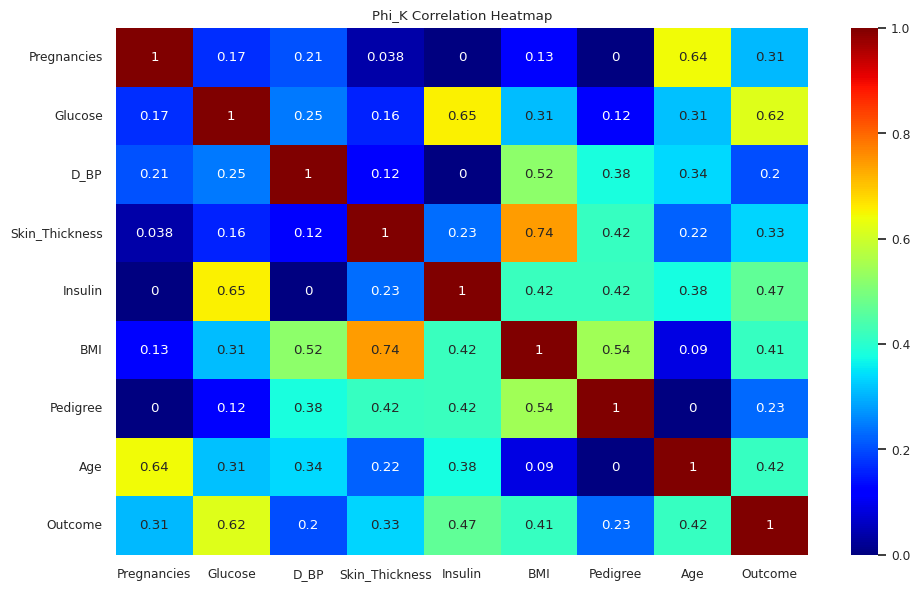

In [17]:
# @title **Phi-K correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

import os
import sys
import subprocess

# Suppress pip install output
subprocess.run([sys.executable, "-m", "pip", "install", "phik"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import phik
from phik import resources, report
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# Identify interval (numerical) columns
interval_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create correlation map using Phi-K
plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

# Compute and plot Phi-K correlation matrix with interval columns specified
phik_corr = df.phik_matrix(interval_cols=interval_cols)
sns.heatmap(phik_corr, annot=True, cmap="jet")

plt.title("Phi_K Correlation Heatmap")
plt.tight_layout()
plt.show()

The code above provides a correlation matrix and heatmap with the Phi-K method. This method is meant for mixed variable types, not just continuous. This still highlights the three main relationships the other two heatmaps do, with also the Glucose and Outcome relationship as the Outcome variable was included. the BMI and Skin Thickness association has an even higher value in this heatmap, and the lowest value is 0, with no negative numbers.

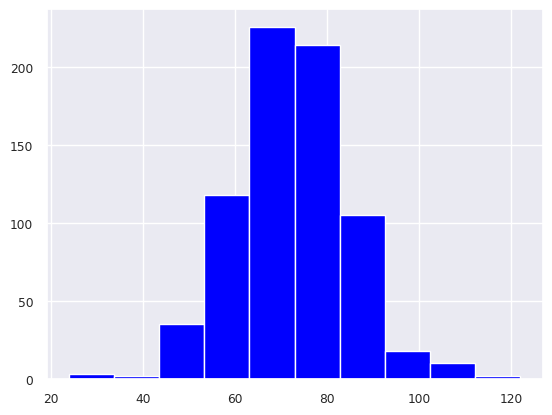

In [18]:
# @title **Example of a histogram**
plt.hist(df['D_BP'], color='blue'); # CHANGE VARIABLE HERE

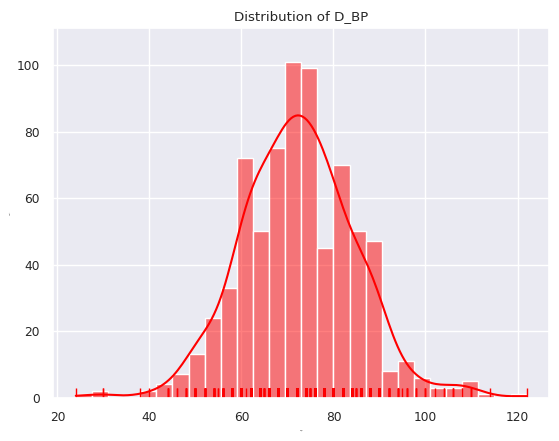

In [19]:
# @title **Example of a distribution plot**

import seaborn as sns
import matplotlib.pyplot as plt

variable = "D_BP"

sns.histplot(data=df, x=variable, color="red", kde=True)
sns.rugplot(data=df, x=variable, color="red")

plt.title(f"Distribution of {variable}")
plt.show()

The plot above combines a histogram, rugplot, and a kernal density estimate plot to display the apparently distribution of the Diastolic Blood Pressure of the sample population.  (https://seaborn.pydata.org/generated/seaborn.kdeplot.html).

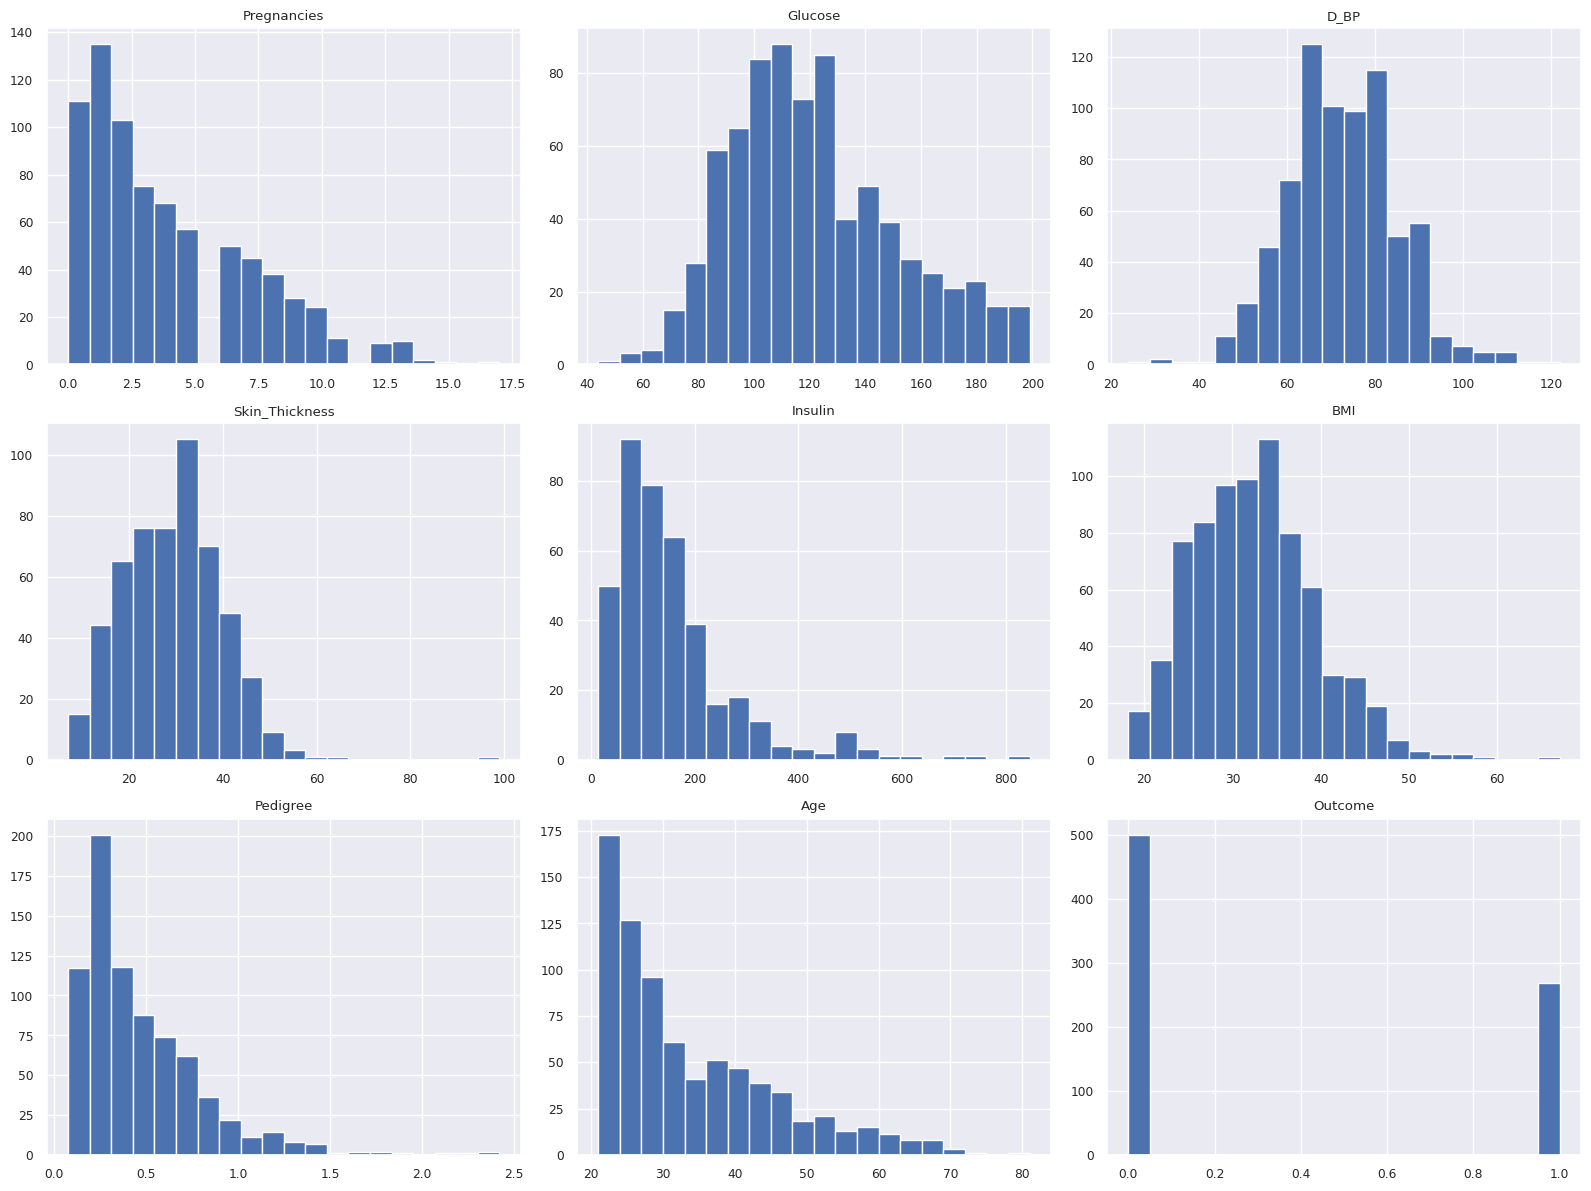

In [20]:
# @title **Generate histograms for all numerical variables**
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

The code above plots the distributions of all the numberic variables without specifying specific dataset information, making it possible to use for different datasets, as long as there are numeric variables. Many of these other plots just have one or two variables named that would need to be or could be changed, depending on the dataset. Still allowing the code to be reused.

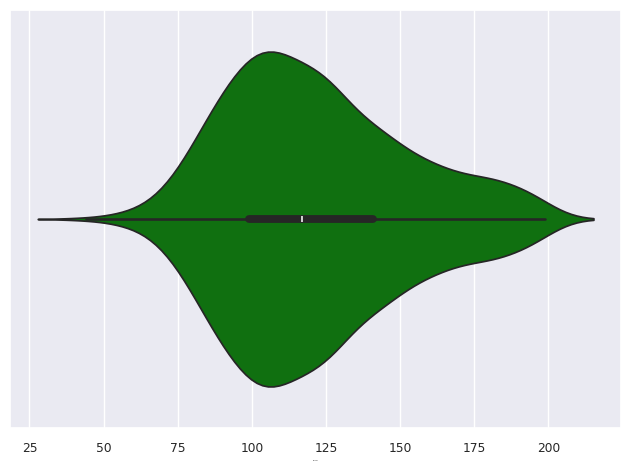

In [21]:
# @title **Example of a violin plot**
sns.violinplot(df['Glucose'], color='green', orient='h'); # CHANGE VARIABLE AND COLOR HERE
plt.tight_layout()

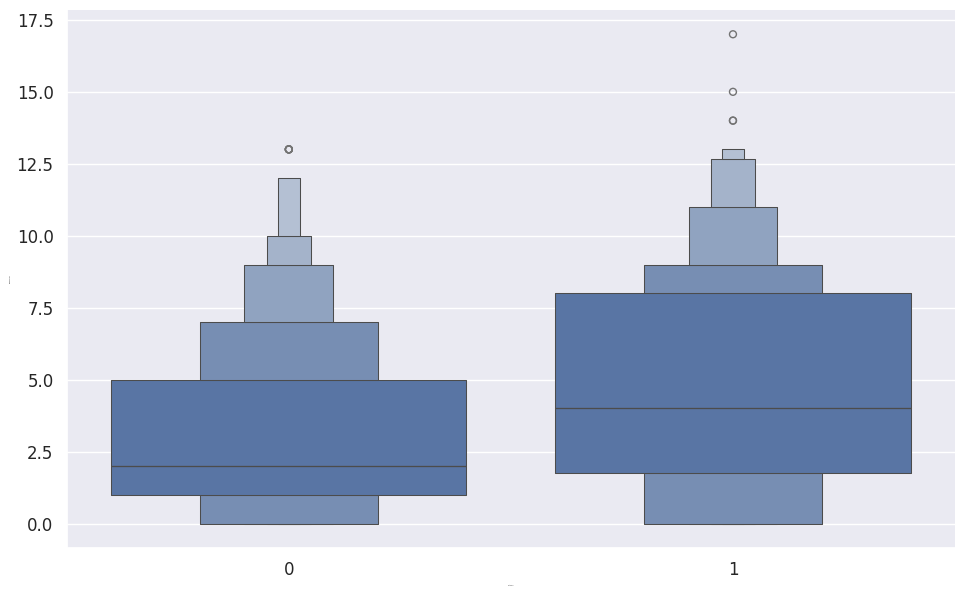

In [22]:
# @title **Example of categorical plot**
# Define the plot variables
x_var = "Outcome"
y_var = "Pregnancies"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the plot
g = sns.catplot(x=x_var, y=y_var, data=df, kind='boxen', height=6, aspect=1.6, estimator=np.mean);

# Dynamically set axis labels
g.set_axis_labels(x_var, y_var)
g.set_titles("{col_name}")

# Optionally set font size
g.set(xlabel=x_var, ylabel=y_var)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [23]:
# @title **Define a function to create a boxplot and histogram combo**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
def histogram_boxplot(feature, figsize=(10,6), bins=None):
    """ Boxplot and histogram combined (horizontal boxplot version)
    feature: 1-d feature array
    figsize: size of fig (default (10,6))
    bins: number of bins (default None / auto)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import norm

    sns.set(font_scale=1)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # Horizontal boxplot
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='red')

    # Histogram
    if bins:
        sns.histplot(feature, kde=False, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(feature, kde=False, ax=ax_hist2)

    # Add central tendency lines to histogram
    ax_hist2.axvline(np.mean(feature), color='black', linestyle='--', label='Mean')
    ax_hist2.axvline(np.median(feature), color='green', linestyle='-', label='Median')
    ax_hist2.axvline(feature.mode()[0], color='red', linestyle='dashed', linewidth=1, label='Mode')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

print("Function successfully created")

Function successfully created


Creating the new function, histogram_boxplot(), allows one to easily plot this type of distribution presentation for all the continuous variables without repeating the above code each time.

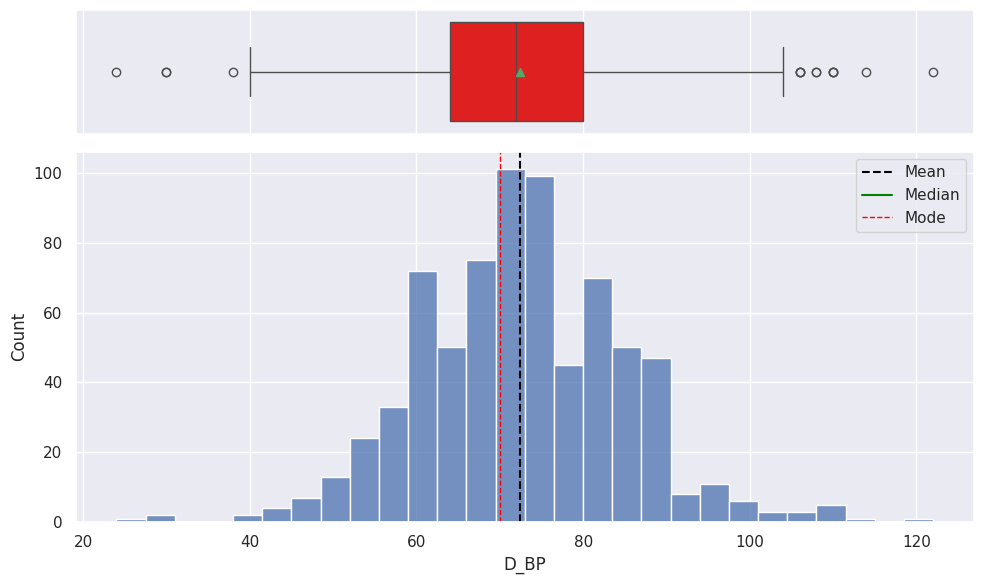

In [24]:
# @title **Example of a combination boxplot and histogram**

histogram_boxplot(df.D_BP) # CHANGE THE CONTINUOUS VARIABLE HERE

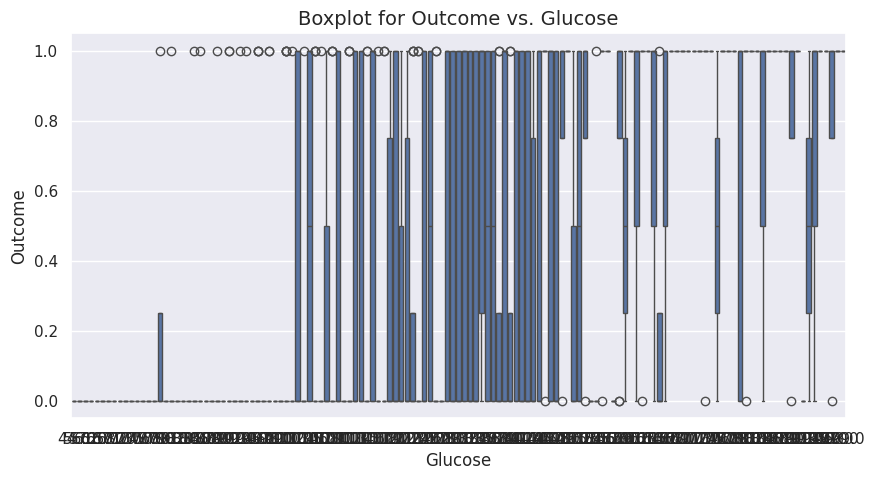

In [25]:
# @title **Example of boxplot with the primary outcome and a continuous variable**

# Define variables
x_var = "Glucose" # CHANGE VARIABLE HERE
y_var = "Outcome"  # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=x_var, y=y_var, data=df)

# Dynamic labels and title
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'Boxplot for {y_var} vs. {x_var}', fontsize=14)

plt.show()

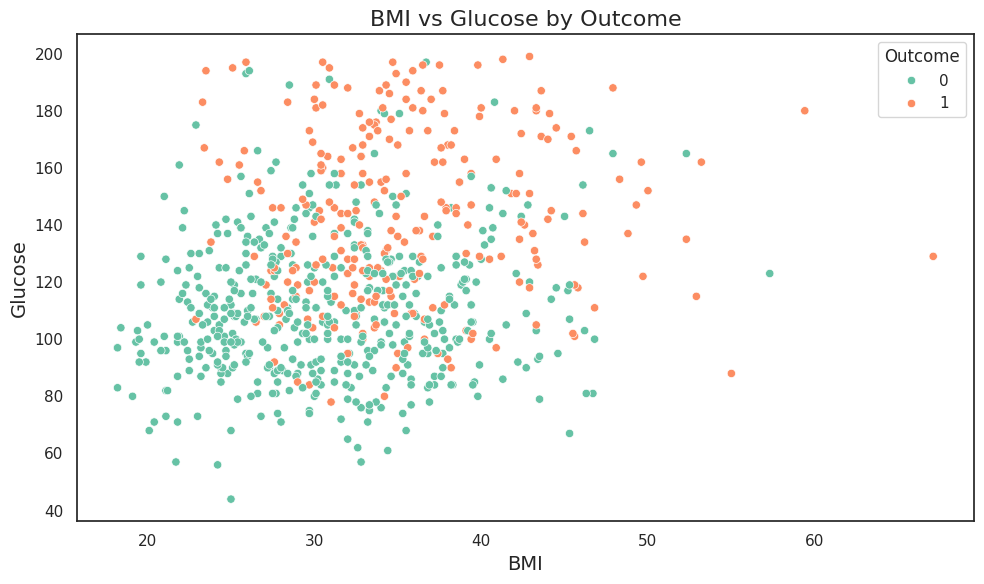

In [26]:
# @title **Example of a scatterplot**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the scatterplot
sns.set(style="white")  # Clean background without gridlines
plt.figure(figsize=(10, 6))

# Scatterplot
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df, palette='Set2')

# Add title and axis labels
plt.title('BMI vs Glucose by Outcome', fontsize=16)
plt.xlabel('BMI', fontsize=14)
plt.ylabel('Glucose', fontsize=14)

# Remove gridlines
plt.grid(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

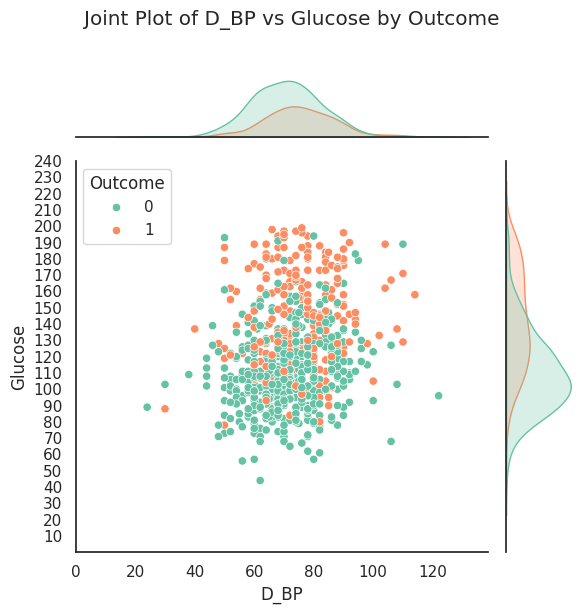

In [27]:
# @title **Example of a joint plot (3 variables)**
x_var = 'D_BP' # CHANGE VARIABLE HERE
y_var = 'Glucose' # CHANGE VARIABLE HERE
outcome = 'Outcome'

g = sns.jointplot(
    x=x_var,
    y=y_var,
    hue=outcome,
    data=df,
    palette='Set2',
    height=6,
)

# Set x-axis and y-axis limits
g.ax_joint.set_xlim(left=0)
g.ax_joint.set_ylim(bottom=0)

# Set y-axis ticks to increase by 10
y_min, y_max = g.ax_joint.get_ylim()
g.ax_joint.set_yticks(np.arange(10, y_max + 10, 10))

# Add title
plt.suptitle(f'Joint Plot of {x_var} vs {y_var} by {outcome}', y=1.02)

plt.tight_layout()
plt.show()

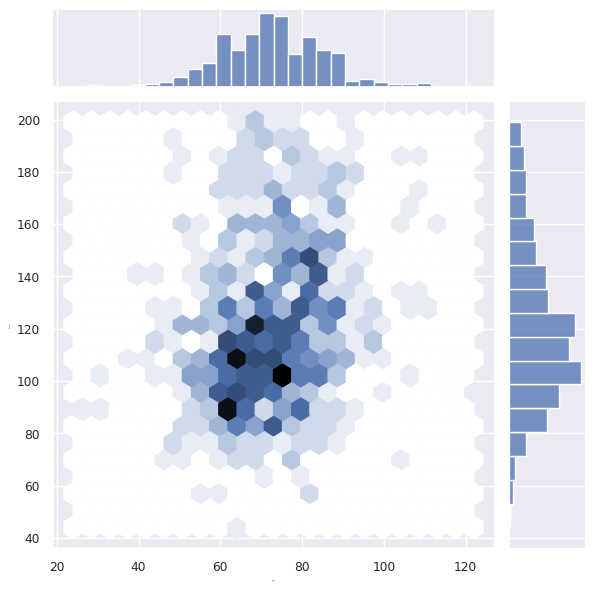

In [28]:
# @title **Example of a joint plot of a different kind (2 variables)**

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='D_BP', # CHANGE VARIABLE HERE
    y='Glucose', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='hex',
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

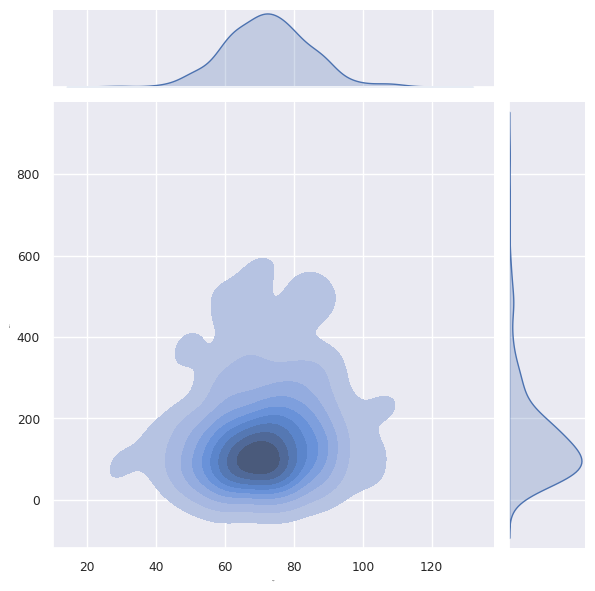

In [29]:
# @title **Another example of a joint plot of a different kind (2 variables)**
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='D_BP', # CHANGE VARIABLE HERE
    y='Insulin', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='kde',
    fill = True,
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

The three different types of joint plots above shows the distribution of two variables and their relationship. The first joint plot also contains a third variable, the outcome, as it is colored by this variable. This plot displays the relationship between Diastolic Blood Pressure and Glucose levels, their individual distributions and the spread of the outcome results for each observation. The second joint plot also shows the relationship between Diastolic Blood Pressure and Glucose levels, while the third join plot shows the relationship between Diastolic blood pressure and Insulin levels.

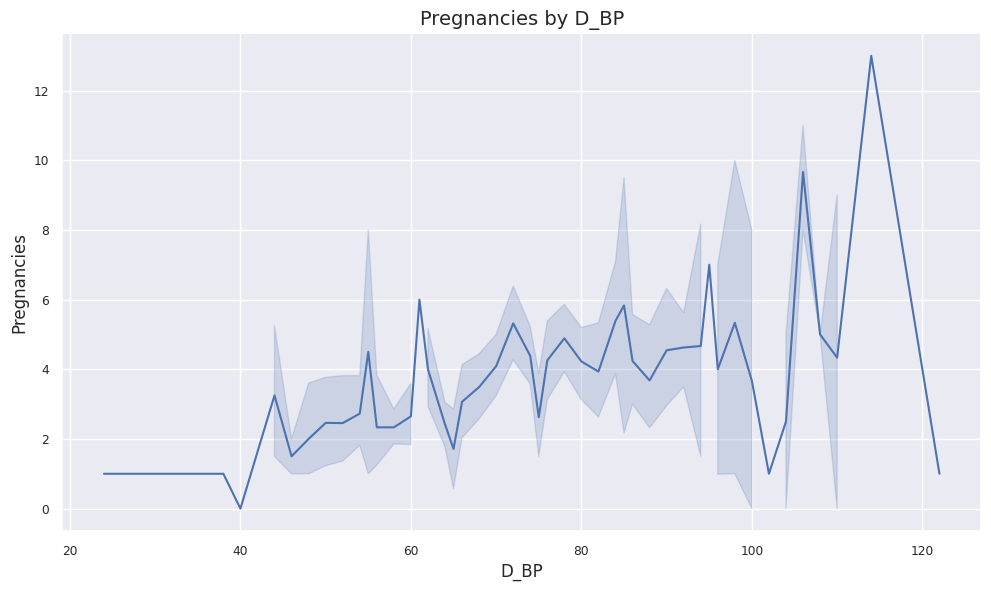

In [30]:
# @title **Example of a line plot**

# Define x and y columns
x_col = 'D_BP' # CHANGE VARIABLE HERE
y_col = 'Pregnancies' # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create lineplot
sns.lineplot(x=x_col, y=y_col, data=df, ax=ax)

# Set axis labels and title explicitly
ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(f'{y_col} by {x_col}', fontsize=14)

# Ensure labels are not cut off
plt.tight_layout()

# Show the plot
plt.show()

This line plot portrays the relationship between diastolic blood pressure and the number of pregnancies.

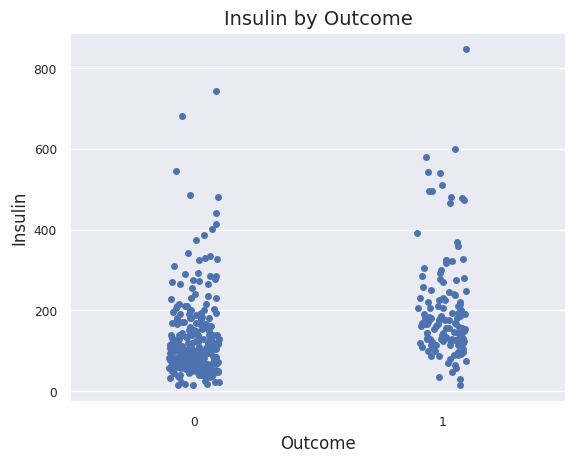

In [31]:
# @title **Example of a strip plot**

# Define axis variables
x_var = "Outcome"  # CHANGE VARIABLE HERE
y_var = "Insulin"      # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
sns.stripplot(data=df, x=x_var, y=y_var, jitter=True)
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

This strip plot shows the distribution of Insulin measurements by each outcome. This code allows for easy change of which variable is plotted, which then also affects the chart title and axes titles.

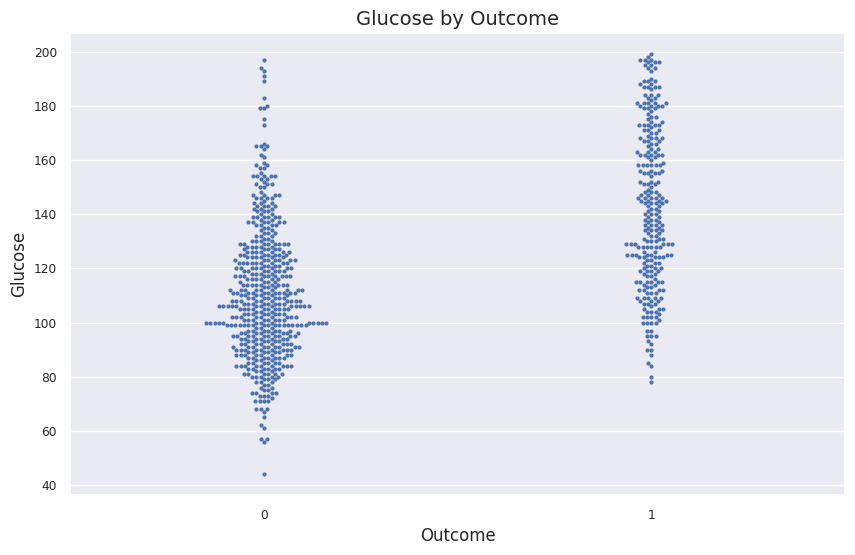

In [32]:
# @title **Example of a swarm plot**

x_var = "Outcome"
y_var = "Glucose"

plt.figure(figsize=(10, 6))
sns.swarmplot(data=df, x=x_var, y=y_var, size=3)

plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

This swarm plot also demonstrates the distribution of a predictor variable for each outcome, but with a different shape, highlighting that for those without diabetes, the majority of the glucose measurements is around 100, while for those with diabetes might have the largest around 125, but it is a lot more spread out.

**Link to other data visualizations: https://seaborn.pydata.org/examples/index.html**

## **Inferential Statistics**

In [33]:
# @title **Import additional inferential statistics libraries**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
import math
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind

print("Libraries successfully imported.")

Libraries successfully imported.


In [34]:
# @title **Example of a one-sample t-test**

from scipy.stats import ttest_1samp

variable = "Glucose"       # CHANGE VARIABLE HERE
threshold = 30        # CHANGE REFERENCE VALUE HERE
alpha = 0.025          # CHANGE SIGNIFICANCE LEVEL HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing observations.
values = df[variable].dropna()

if len(values) < 2 or values.std() == 0:
    raise ValueError(
        "The test requires at least two nonmissing values and nonzero variance."
    )

# Perform a two-sided one-sample t-test.
t_statistic, p_value = ttest_1samp(values, popmean=threshold)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"is {direction} than {threshold}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence that the population mean "
        f"{variable} differs from {threshold}."
    )

print(f"Null hypothesis: The population mean {variable} equals {threshold}.")
print(f"Alternative hypothesis: The population mean {variable} differs from {threshold}.")
print(f"\nNonmissing observations: {len(values)}")
print(f"Sample mean: {values.mean():.3f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean Glucose equals 30.
Alternative hypothesis: The population mean Glucose differs from 30.

Nonmissing observations: 763
Sample mean: 121.687
t-statistic: 82.940
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean Glucose is higher than 30.


The code above for the one-sample t-test ises multiple conditional logic to provide the output or result based on specific thresholds and provide descriptive summaries of the results. There are multiple different descriptive summaries, one for each result taken into account. The one-sample t-test rejects the null hypothesis that the population mean of the Glucose measurements equals 30, because the p-value was calculated to be < 0.001. Because the t-statistic was greater than 0, the interpretation also included taht the population mean was likely to be higher than 30.

In [35]:
# @title **Independent samples t-test (specific to this dataset)**

from scipy.stats import ttest_ind

variable = "D_BP"
group_col = "Outcome"
alpha = 0.05

label_map = {0: "Patients without diabetes", 1: "Patients with diabetes"}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing either the measurement or group.
test_data = df[[variable, group_col]].dropna()

if set(test_data[group_col].unique()) != {0, 1}:
    raise ValueError("The group variable must contain both groups, coded 0 and 1.")

# Set a consistent comparison order.
group1 = test_data.loc[test_data[group_col] == 0, variable]
group2 = test_data.loc[test_data[group_col] == 1, variable]

if len(group1) < 2 or len(group2) < 2:
    raise ValueError("Each group requires at least two nonmissing observations.")

if group1.var() == 0 and group2.var() == 0:
    raise ValueError("The test requires variation in at least one group.")

group1_name = label_map[0]
group2_name = label_map[1]

# Two-sided Welch's t-test.
t_statistic, p_value = ttest_ind(group1, group2, equal_var=False)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"for {group1_name.lower()} is {direction} than "
        f"for {group2_name.lower()}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference in population "
        f"mean {variable} between the two groups."
    )

print(f"Null hypothesis: The population mean {variable} is equal between groups.")
print(f"Alternative hypothesis: The population mean {variable} differs between groups.")

print(f"\n{group1_name}: n = {len(group1)}, mean = {group1.mean():.3f}")
print(f"{group2_name}: n = {len(group2)}, mean = {group2.mean():.3f}")
print(f"Mean difference (group 0 − group 1): {group1.mean() - group2.mean():.3f}")

print(f"\nWelch's independent samples t-test:")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean D_BP is equal between groups.
Alternative hypothesis: The population mean D_BP differs between groups.

Patients without diabetes: n = 481, mean = 70.877
Patients with diabetes: n = 252, mean = 75.321
Mean difference (group 0 − group 1): -4.444

Welch's independent samples t-test:
t-statistic: -4.664
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean D_BP for patients without diabetes is lower than for patients with diabetes.


The code for the independent samples t-test uses multiple instances of condtional logic. First, to ensure that the criteria for running the test are met, and if not, a specific error message will be returned. Then, after running the test, conditional logic is used to present the results in a very organized and easily understood way. For example, instead of just returning the p-value, there's a line that states if the p-value is < 0.001, then just return p < 0.001. Then based on this result and the set alpha value, a decision is returned on whether to reject the null or not. It also returns the direction of the difference, if different, based on the t-statistic. Throughout, the variable being compared and the outcome only need to be mentioned once, at the very beginning.

In [36]:
# @title **One-way ANOVA (specific to this dataset)**

import statsmodels.api as sm
from statsmodels.formula.api import ols

variable = "Glucose"
group_col = "Outcome"
alpha = 0.05

label_map = {
    0: "Patients without diabetes",
    1: "Patients with diabetes"
}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing the measurement or group.
test_data = df[[variable, group_col]].dropna().copy()

# Use standard column names for the model formula.
test_data.columns = ["measurement", "group"]
test_data["group"] = test_data["group"].astype("category")
test_data["group"] = test_data["group"].cat.remove_unused_categories()

group_summary = (
    test_data.groupby("group", observed=True)["measurement"]
    .agg(["count", "mean", "std"])
)

if len(group_summary) < 2:
    raise ValueError("ANOVA requires at least two groups.")

if (group_summary["count"] < 2).any():
    raise ValueError("Each group requires at least two nonmissing observations.")

if (group_summary["std"] == 0).all():
    raise ValueError("The test requires variation within at least one group.")

# Fit the model and calculate the ANOVA table.
anova_model = ols("measurement ~ C(group)", data=test_data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

f_stat = anova_table.loc["C(group)", "F"]
p_value = anova_table.loc["C(group)", "PR(>F)"]

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    interpretation = (
        f"There is evidence that at least two groups differ "
        f"in population mean {variable}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference "
        f"in population mean {variable} across groups."
    )

# Apply readable group labels for display.
group_summary.index = [
    label_map.get(group, str(group))
    for group in group_summary.index
]

print(f"Null hypothesis: Population mean {variable} is equal across all groups.")
print(f"Alternative hypothesis: At least one population mean differs.")

print("\nGroup summaries:")
display(group_summary.round(3))

print("\nANOVA table:")
display(anova_table.round(3))

print(f"\nF-statistic: {f_stat:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: Population mean Glucose is equal across all groups.
Alternative hypothesis: At least one population mean differs.

Group summaries:


,count,mean,std
Patients without diabetes,497,110.644,24.777
Patients with diabetes,266,142.320,29.599



ANOVA table:


,sum_sq,df,F,PR(>F)
C(group),173846.334,1.0,246.518,0.0
Residual,536661.802,761.0,NaN,NaN



F-statistic: 246.518
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that at least two groups differ in population mean Glucose.


The conditional logic used in the code for the ANOVA analysis was used very similarly to how it was used for the two-sample t-test. Starting with ensuring the assumptions and criteria of the analysis are met, but then also provides specific interpretations for the ANOVA. These codes can be reproduced for another dataset, as long as the variables fit the parameters.

In [37]:
# @title **Chi-square test of independence (specific to this dataset)**

import pandas as pd
from scipy.stats import chi2_contingency

group_col = "Outcome"
variable = "Pregnancies"
threshold = 10
alpha = 0.05

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing values before creating categories.
test_data = df[[group_col, variable]].dropna().copy()
test_data["Above threshold"] = test_data[variable] > threshold

crosstab = pd.crosstab(
    test_data[group_col],
    test_data["Above threshold"]
)

if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
    raise ValueError("The test requires at least two observed categories per variable.")

# Run Pearson's chi-square test without continuity correction.
chi2_stat, p_value, dof, expected = chi2_contingency(
    crosstab, correction=False
)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

print("Observed counts (False = ≤ threshold; True = > threshold):")
display(crosstab)

print("\nExpected counts under independence:")
display(pd.DataFrame(
    expected,
    index=crosstab.index,
    columns=crosstab.columns
).round(3))

print(f"\nNull hypothesis: {group_col} and {variable} > {threshold} are independent.")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p {formatted_p}")

if (expected < 5).any():
    print(
        "\nSmall expected counts detected. For this 2×2 table, "
        "consider Fisher's exact test before interpreting the chi-square result."
    )

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print(
        f"Interpretation: There is evidence of an association between "
        f"{group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )
else:
    print("Decision: Fail to reject the null hypothesis.")
    print(
        f"Interpretation: There is insufficient evidence of an association "
        f"between {group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )

Observed counts (False = ≤ threshold; True = > threshold):


Above threshold,False,True
Outcome,,
0,486,14
1,248,20



Expected counts under independence:


Above threshold,False,True
Outcome,,
0,477.865,22.135
1,256.135,11.865



Null hypothesis: Outcome and Pregnancies > 10 are independent.
Chi-square statistic: 8.965
Degrees of freedom: 1
p = 0.003
Decision: Reject the null hypothesis.
Interpretation: There is evidence of an association between Outcome and having Pregnancies > 10, provided the test assumptions are met.


In the code above for the Chi-square test, but also in previous code chunks, the missing values were only removed for that specific analysis instead of completely removing them from the data frame or creating a clean data frame, allowing the variables that have different missing values to maintain the maximum information.

In [38]:
# @title **Encode outcome labels as 0 and 1 (if needed)**

target_variable = "Outcome"
label_map = {"No Diabetes": 0, "Diabetes": 1}

outcome = df[target_variable]
observed_values = set(outcome.dropna().unique())

if observed_values.issubset({0, 1}):
    print("Outcome is already coded as 0/1.")

elif observed_values.issubset(set(label_map)):
    df[target_variable] = outcome.map(label_map)
    print("Outcome labels converted to 0/1.")

else:
    raise ValueError(
        f"Unexpected outcome values: {observed_values}. "
        "Update label_map to match your dataset."
    )

display(df[target_variable].head(10))

Outcome is already coded as 0/1.


,Outcome
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,0
8,1
9,1


Encoding the outcome labels as 0 and 1 allows for the analysis code to be reused for other datasets, instead of having to change the column titles everytime. But visualizations and interpretations should be re-translated for clarity.

## **Supervised Machine Learning (Binary Classification)**

**Two examples:**
- Logistic Regression  
- Decision Tree  

**LOGISTIC REGRESSION:** Additional Info on Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## **Logistic Regression**

In [39]:
# @title **Configure and split data for the automated ML pipeline**

from sklearn.model_selection import train_test_split

target_variable = "Outcome"  # CHANGE FOR YOUR DATASET

# Exclude rows with missing outcomes; do not impute the outcome.
ml_data = df.dropna(subset=[target_variable]).copy()

X = ml_data.drop(columns=[target_variable])
y = ml_data[target_variable]

# This demonstration expects numeric predictors and an outcome coded 0/1.
if set(y.unique()) != {0, 1}:
    raise ValueError("The outcome must contain both classes, coded 0 and 1.")

if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
    raise ValueError("This pipeline requires numeric predictors.")

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Training observations: 537
Test observations: 231


The above code ensures the dataset and types fit this specific analysis model with conditional logic, before splitting the data into training and test sets.

In [40]:
# @title **Define a function to display a confusion matrix**

from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_actual, y_predict):
    """Display counts and percentages of all evaluated observations."""

    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])

    if cm.sum() == 0:
        raise ValueError("No observations with labels 0 or 1 to display.")

    cell_names = np.array([
        ["True negative", "False positive"],
        ["False negative", "True positive"]
    ])

    annotations = np.array([
        f"{name}\n{count}\n{count / cm.sum():.2%}"
        for name, count in zip(cell_names.flatten(), cm.flatten())
    ]).reshape(2, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title(f"{model_name}: Test Set")
    plt.tight_layout()
    plt.show()

print("Function successfully created.")

Function successfully created.


In [41]:
# @title **Build logistic regression with automated preprocessing**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Learn imputation and scaling from training data only.
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Apply the fitted preprocessing and model to test data.
y_predict = logistic_pipeline.predict(X_test)
model_score = logistic_pipeline.score(X_test, y_test)

print(f"Test-set accuracy: {model_score:.2%}")
print(
    f"The model correctly classified {model_score:.2%} "
    "of observations in the test set."
)

Test-set accuracy: 74.46%
The model correctly classified 74.46% of observations in the test set.


Imputation does not occur until this code chunk, ensuring that the imputation only uses the information in the training data, or else the accuracy of the model would be biased towards the test data.

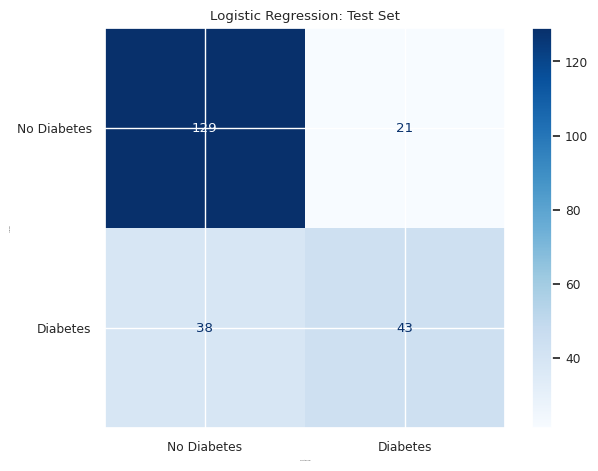

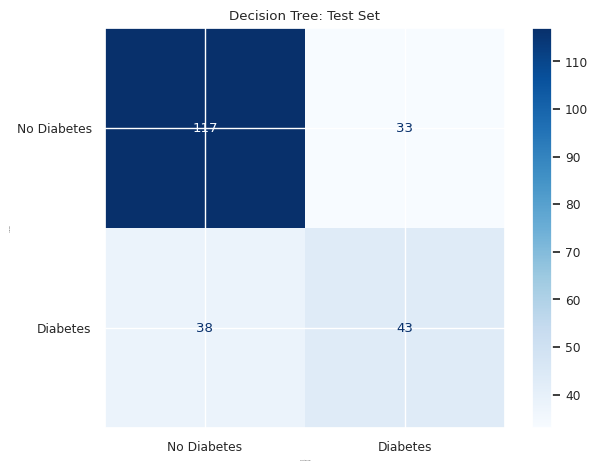

Test-set performance:


,Accuracy,Recall,Precision,F1,ROC AUC
Model,,,,,
Logistic Regression,0.745,0.531,0.672,0.593,0.836
Decision Tree,0.693,0.531,0.566,0.548,0.655


In [42]:
# @title **Automatically preprocess, train, and evaluate ML models**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Define the models to run automatically.
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

trained_pipelines = {}
results = []

for model_name, classifier in models.items():

    # Preprocessing is fitted using training data only.
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Apply scaling when appropriate for the model.
    if isinstance(classifier, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", classifier))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    positive_index = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_index]

    trained_pipelines[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["No Diabetes", "Diabetes"],
        cmap="Blues"
    )
    plt.title(f"{model_name}: Test Set")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).set_index("Model")

print("Test-set performance:")
display(results_df.round(3))

In almost all of the five metrics, the Logistic Regression model performs better than the Decision Tree model. For the Recall metric, both models received the same score of 0.531. This suggests that the Logistic Regression model was correct overall more often, with a lower percentages of falsely identifying an instance as with diabetes, while both models can correctly identify those with diabetes equally well.

### Remaking the above Confusion Matrices with the function created earlier in the notebook.
The beginning of this code chunk is the same as the above chunk as both models still needed to be trained and then tested and both models were already written out to run automatically and print a confusion matrix and fill the metrics table. However, the ConfusionMatrixDisplay.from_predictions() function was replaced by the make_confusion_matrix() function created earlier in the notebook, allowing for the details of the matrix plot to already be decided, instead of relying on the same code chunk running the models. These confusion matrices are more informative by specifying which axis is the Actual and which is the Predicted. I was trying to figure out if I could replace the 0 and 1 with the "No diabetes" and "Diabetes" used in the above matrices without specifying, so that the code could still be used for another dataset, but that did not work this time.

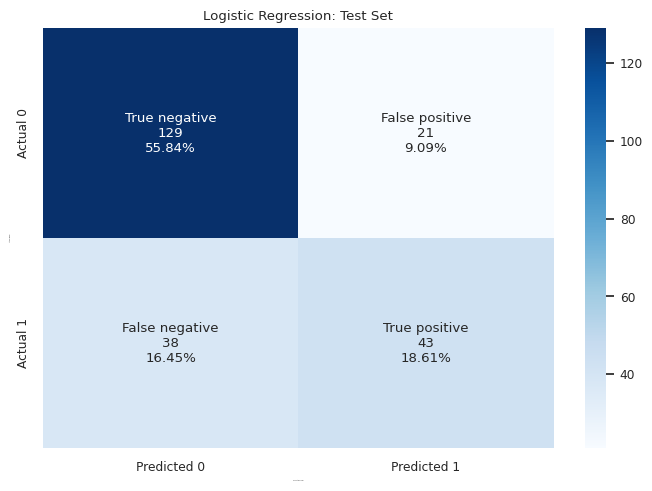

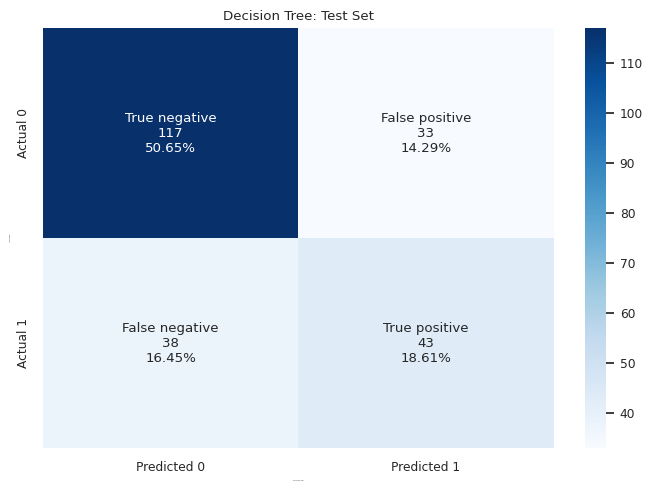

Test-set performance:


,Accuracy,Recall,Precision,F1,ROC AUC
Model,,,,,
Logistic Regression,0.745,0.531,0.672,0.593,0.836
Decision Tree,0.693,0.531,0.566,0.548,0.655


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

# Define the models to run automatically.
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

trained_pipelines = {}
results = []

for model_name, classifier in models.items():

    # Preprocessing is fitted using training data only.
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Apply scaling when appropriate for the model.
    if isinstance(classifier, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", classifier))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    positive_index = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_index]

    trained_pipelines[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

    make_confusion_matrix(
        y_test,
        predictions
    )

results_df = pd.DataFrame(results).set_index("Model")

print("Test-set performance:")
display(results_df.round(3))

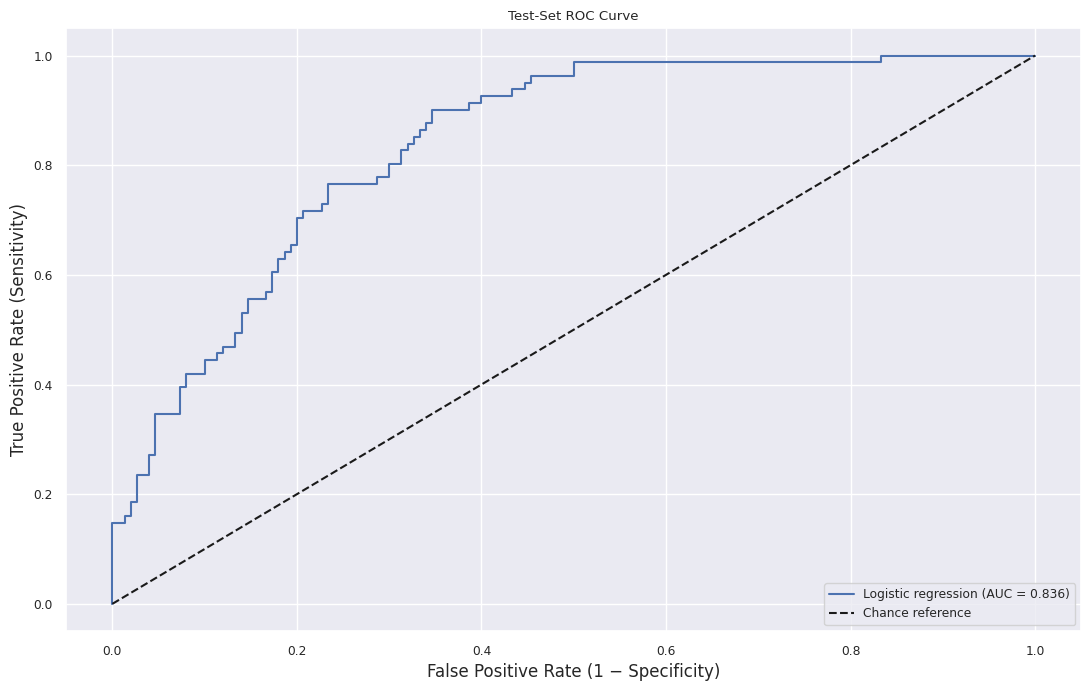

Test-set ROC AUC: 0.836


In [44]:
# @title **ROC curve and AUC for logistic regression**

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (1).
positive_index = list(logistic_pipeline.classes_).index(1)
y_probability = logistic_pipeline.predict_proba(X_test)[:, positive_index]

# Calculate test-set ROC AUC and curve.
logit_roc_auc = roc_auc_score(y_test, y_probability)
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(11, 7))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {logit_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance reference")
plt.xlabel("False Positive Rate (1 − Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("Test-Set ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Test-set ROC AUC: {logit_roc_auc:.3f}")

As the Logistic Regression model has a higher AUC value than the Decision Tree model, the Logistic Regression model has more area under the ROC curve, which must then be closer to the top left corner, representing a perfect model. This means the False Positve Rate can be lower for a higher True Positive Rate, when compared to the Decision Tree model.

In [45]:
# @title **Select a cutoff using training-set cross-validation**

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Use the logistic_pipeline defined in the training block.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

# Each observation is predicted by a pipeline trained on other folds.
# Imputation and scaling are learned separately within each fold.
cv_probabilities = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)

positive_index = list(logistic_pipeline.classes_).index(1)

fpr, tpr, thresholds = roc_curve(
    y_train,
    cv_probabilities[:, positive_index]
)

# Exclude the infinite threshold representing no positive predictions.
finite = np.isfinite(thresholds)
j_scores = tpr[finite] - fpr[finite]
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[finite][optimal_idx]

print(f"Selected threshold: {optimal_threshold:.3f}")
print("Criterion: maximum cross-validation sensitivity + specificity − 1.")
print("Apply this cutoff to the fitted pipeline's test-set probabilities.")

Selected threshold: 0.443
Criterion: maximum cross-validation sensitivity + specificity − 1.
Apply this cutoff to the fitted pipeline's test-set probabilities.


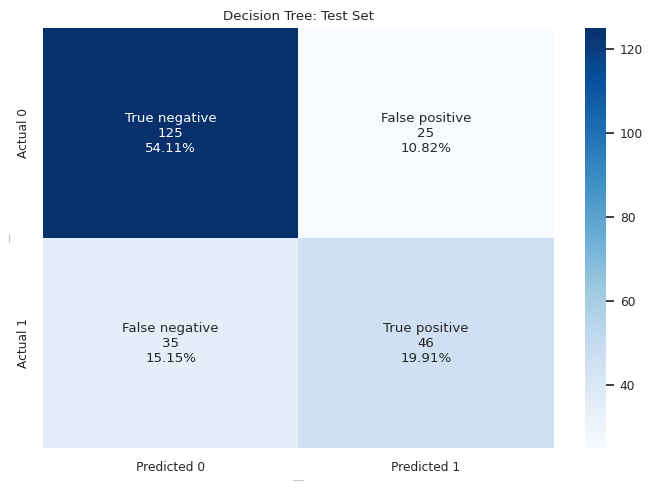

In [46]:
# @title **Make confusion matrix using the selected cutoff**

positive_index = list(logistic_pipeline.classes_).index(1)

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

make_confusion_matrix(y_test, y_pred_ts)

Creating the function, make_confusion_matrix() earlier in the notebook, greatly reduced the amount of code needed to create this confusion matrix after applying the cut-off threshold. It also resulted in more information automatically showing up to the matrix. The labels are also neutral for other datasets, but still descriptive.

In [47]:
# @title **Compare training and test F1 at the selected cutoff**

from sklearn.metrics import f1_score

positive_index = list(logistic_pipeline.classes_).index(1)

train_probabilities = logistic_pipeline.predict_proba(
    X_train
)[:, positive_index]

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_tr = (train_probabilities >= optimal_threshold).astype(int)
y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

print(f"Selected cutoff: {optimal_threshold:.3f}")
print(f"Training F1: {f1_score(y_train, y_pred_tr, zero_division=0):.3f}")
print(f"Test F1: {f1_score(y_test, y_pred_ts, zero_division=0):.3f}")

Selected cutoff: 0.443
Training F1: 0.669
Test F1: 0.605


Combining the above two code chunks in order to remove the repeated lines of code. The test prediction values at the selected cutoff are used in the new confusion matrix and when comparing the training and testing F1.

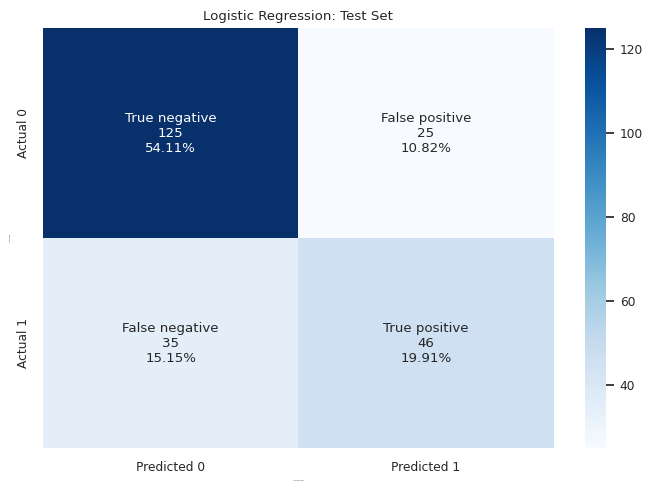

Selected cutoff: 0.443
Training F1: 0.669
Test F1: 0.605


In [57]:
# @title **Make confusion matrix using the selected cutoff and compare the training and test F1 at the selected cutoff**

model_name = "Logistic Regression"

positive_index = list(logistic_pipeline.classes_).index(1)

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

make_confusion_matrix(y_test, y_pred_ts)

# Complete calculation for the training set and then calculate F1 for both the training and test set at the selected cutoff.

train_probabilities = logistic_pipeline.predict_proba(
    X_train
)[:, positive_index]

y_pred_tr = (train_probabilities >= optimal_threshold).astype(int)

print(f"Selected cutoff: {optimal_threshold:.3f}")
print(f"Training F1: {f1_score(y_train, y_pred_tr, zero_division=0):.3f}")
print(f"Test F1: {f1_score(y_test, y_pred_ts, zero_division=0):.3f}")


## **Decision Tree**

**DECISION TREE: https://scikit-learn.org/stable/modules/tree.html#**

In [49]:
# @title **Import libraries for decision tree training and evaluation**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Decision tree libraries imported successfully.")

Decision tree libraries imported successfully.


In [50]:
# @title **Build and tune decision tree using cross-validation F1**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Choose the metric used for tuning.
scoring_metric = "f1"  # Alternatives: "recall", "precision", "accuracy"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

dtree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Pipeline parameters require the step name prefix.
parameters = {
    "classifier__max_depth": [2, 4, 6, 8],
    "classifier__min_samples_leaf": [5, 10, 15],
    "classifier__max_leaf_nodes": [5, 10, 15],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

grid_obj = GridSearchCV(
    estimator=dtree_pipeline,
    param_grid=parameters,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_obj.fit(X_train, y_train)

# Already refitted on the full training set; no additional fit is needed.
dtree = grid_obj.best_estimator_

print("Decision tree pipeline built and tuned.")
print(f"Best mean cross-validation {scoring_metric}: {grid_obj.best_score_:.3f}")
print("Selected parameters:")
print(grid_obj.best_params_)

Decision tree pipeline built and tuned.
Best mean cross-validation f1: 0.682
Selected parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__max_leaf_nodes': 10, 'classifier__min_samples_leaf': 5}


Defining the scoring metric at the top of the code allows an easy switch in the desired metric, depending on what is needed, allowing the chunk of code to be reused with other datasets.

In [51]:
# @title **Function to calculate accuracy, recall, precision, and F1**

from sklearn import metrics

def get_metrics_score(model, flag=True):
    """Evaluate a fitted classifier on the existing training and test sets."""

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(y_train, pred_train)
    test_acc = metrics.accuracy_score(y_test, pred_test)

    train_recall = metrics.recall_score(
        y_train, pred_train, zero_division=0
    )
    test_recall = metrics.recall_score(
        y_test, pred_test, zero_division=0
    )

    train_precision = metrics.precision_score(
        y_train, pred_train, zero_division=0
    )
    test_precision = metrics.precision_score(
        y_test, pred_test, zero_division=0
    )

    train_f1 = metrics.f1_score(y_train, pred_train, zero_division=0)
    test_f1 = metrics.f1_score(y_test, pred_test, zero_division=0)

    score_list = [
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ]

    if flag:
        print(f"{'Metric':<12} {'Training':>10} {'Test':>10}")
        for name, train_value, test_value in [
            ("Accuracy", train_acc, test_acc),
            ("Recall", train_recall, test_recall),
            ("Precision", train_precision, test_precision),
            ("F1", train_f1, test_f1)
        ]:
            print(f"{name:<12} {train_value:>10.3f} {test_value:>10.3f}")

    return score_list

print("Metric evaluation function successfully defined.")

Metric evaluation function successfully defined.


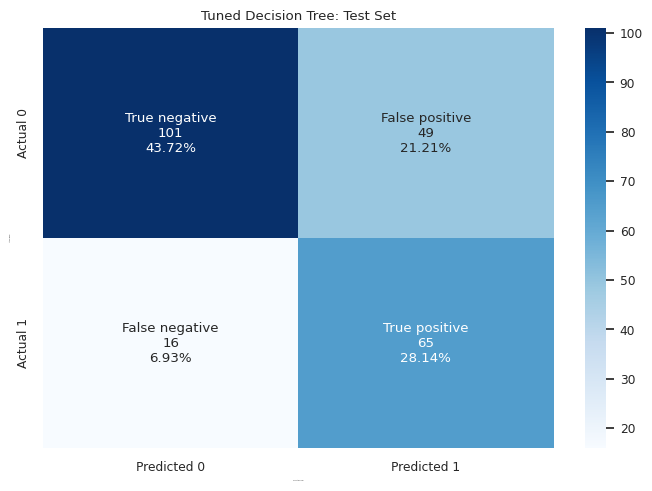

In [59]:
# @title **Display confusion matrix for the tuned decision tree**

model_name = "Tuned Decision Tree"

y_pred_tree = dtree.predict(X_test)

make_confusion_matrix(y_test, y_pred_tree)

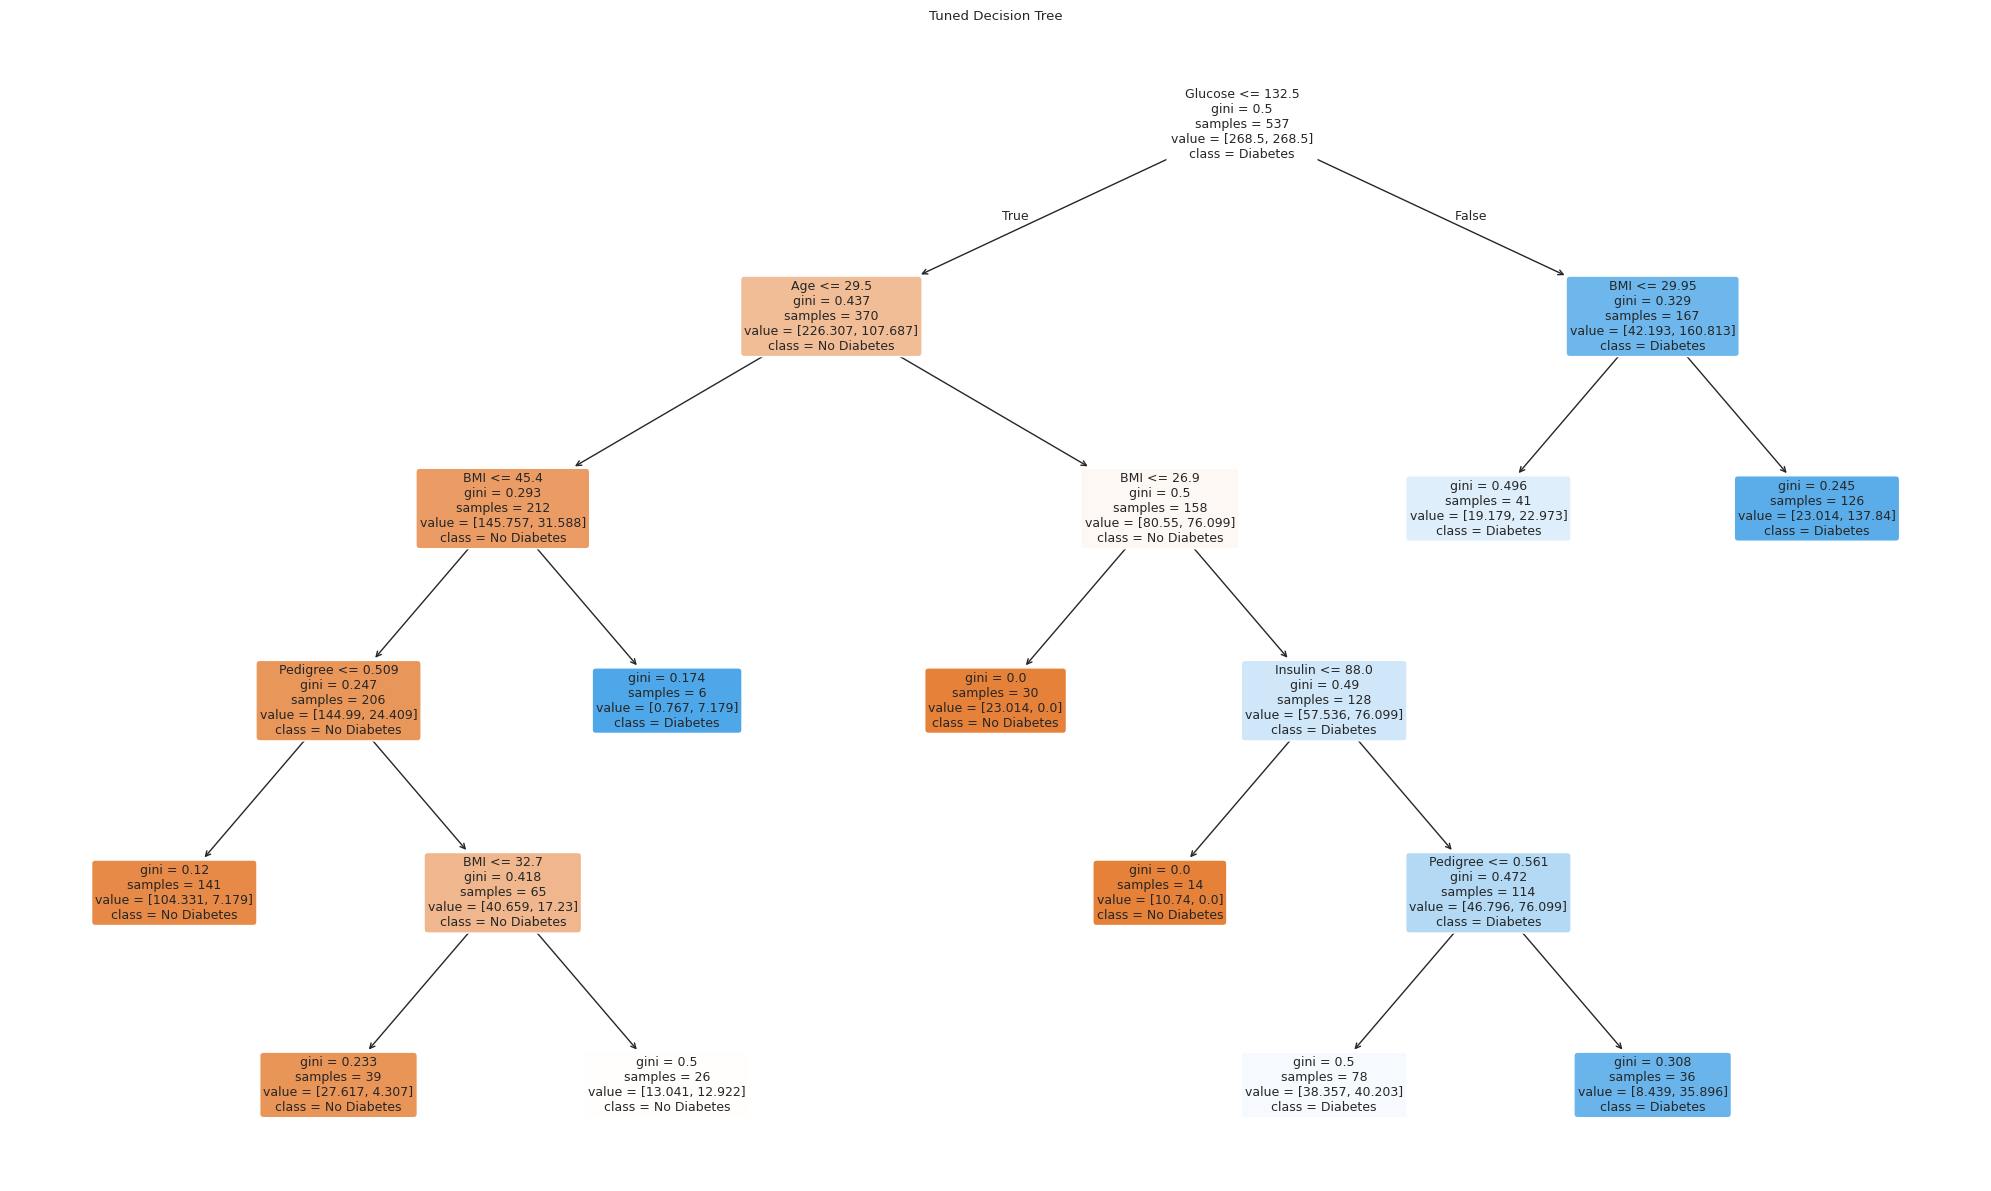

In [53]:
# @title **Show the tuned decision tree**

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

plt.figure(figsize=(20, 12))

plot_tree(
    tree_classifier,
    feature_names=list(feature_names),
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9,
    node_ids=False
)

plt.title("Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [54]:
# @title **List feature importance from the tuned decision tree**

import pandas as pd

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.reset_index(drop=True).round(3))

,Feature,Importance
0,Glucose,0.464
1,BMI,0.265
2,Age,0.131
3,Pedigree,0.076
4,Insulin,0.063
5,Skin_Thickness,0.000
6,Pregnancies,0.000
7,D_BP,0.000


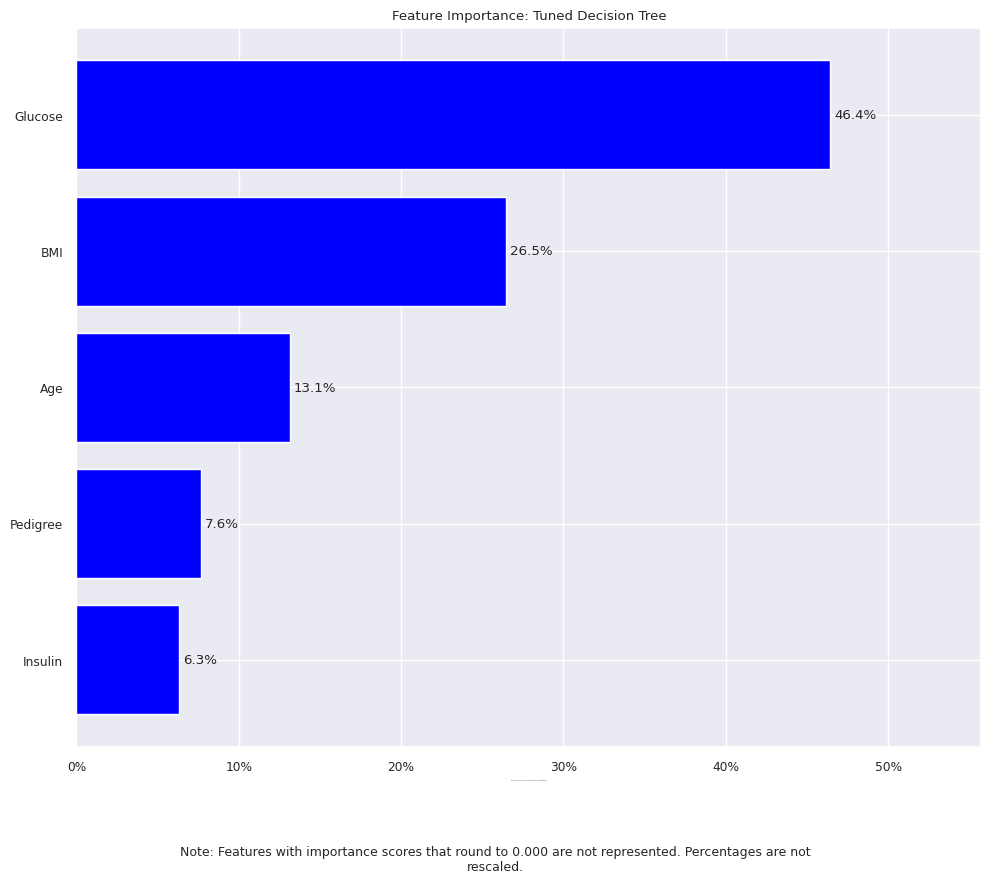

Highest-ranked features in this fitted tree:
- Glucose: 46.4%
- BMI: 26.5%
- Age: 13.1%

Excluded features (importance rounds to 0.000): Pregnancies, D_BP, Skin_Thickness

These percentages describe each feature's share of total impurity reduction, not its effect on diabetes risk.


In [55]:
# @title **Visualize feature importance from the tuned decision tree**

import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.ticker import PercentFormatter

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()
importances = tree_classifier.feature_importances_

# Exclude scores that round to 0.000 at three decimal places.
included = np.round(importances, 3) > 0
excluded_features = feature_names[~included].tolist()

excluded_note = (
    "Excluded features (importance rounds to 0.000): "
    + ", ".join(excluded_features)
    if excluded_features
    else "No features were excluded."
)

if included.any():
    shown_names = feature_names[included]
    shown_importances = importances[included]
    indices = np.argsort(shown_importances)

    note = textwrap.fill(
        "Note: Features with importance scores that round to 0.000 "
        "are not represented. Percentages are not rescaled.",
        width=100
    )
    note_lines = len(note.splitlines())
    bottom_margin = 0.6 + 0.18 * note_lines
    figure_height = 8 + bottom_margin

    fig, ax = plt.subplots(figsize=(10, figure_height))

    bars = ax.barh(
        range(len(indices)),
        shown_importances[indices],
        color="blue"
    )

    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(shown_names[indices])
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in shown_importances[indices]],
        padding=3
    )

    ax.set_xlim(0, shown_importances.max() * 1.2)
    ax.set_xlabel("Feature Importance (% of total impurity reduction)")
    ax.set_title("Feature Importance: Tuned Decision Tree")

    fig.text(
        0.5, 0.02,
        note,
        ha="center",
        va="bottom",
        fontsize=9
    )

    plt.tight_layout(
        rect=[0, bottom_margin / figure_height, 1, 1]
    )
    plt.show()

    print("Highest-ranked features in this fitted tree:")
    for index in indices[::-1][:3]:
        print(f"- {shown_names[index]}: {shown_importances[index]:.1%}")

else:
    print("All feature importance scores round to 0.000; no graph displayed.")

print(f"\n{excluded_note}")
print(
    "\nThese percentages describe each feature's share of total "
    "impurity reduction, not its effect on diabetes risk."
)

The automatic documentation of what has been excluded and why is a very important element for reproducility and even just for another person to interpret. The reuse of this code with other datasets helps keep that level of documentation consistent, especially with following the same criteria.